✅ Loading Experiment ID: 1
[A. Standard] Running t-SNE Manifold...
[A. Standard] Identifying Phenotypes...
[B. Semantic] Running t-SNE Manifold...
[B. Semantic] Identifying Phenotypes...


Metric,Mean,Shift,Vis
Mechanistic,0.958,-1.0 SD,
LogitGap,0.328,+3.2 SD,
Heuristic,0.447,+0.1 SD,
TraceLength,134.650,-0.8 SD,
SemanticEntropy,0.091,-0.6 SD,
Metric,Mean,Shift,Vis
Mechanistic,0.968,+0.1 SD,
LogitGap,0.051,-0.2 SD,
Heuristic,0.478,+0.8 SD,
TraceLength,190.035,+0.2 SD,

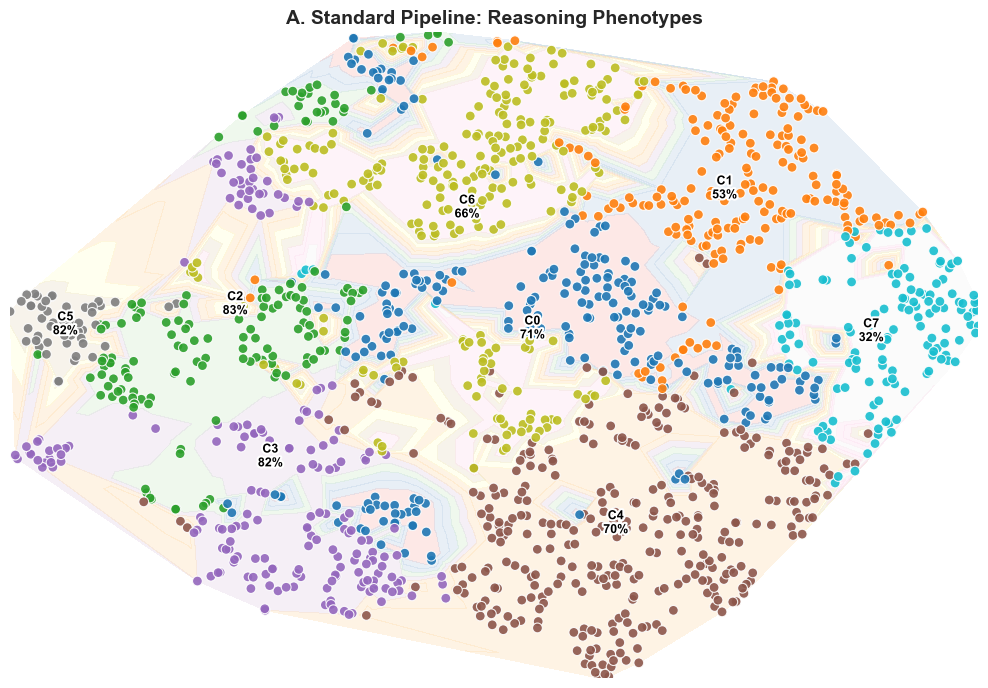
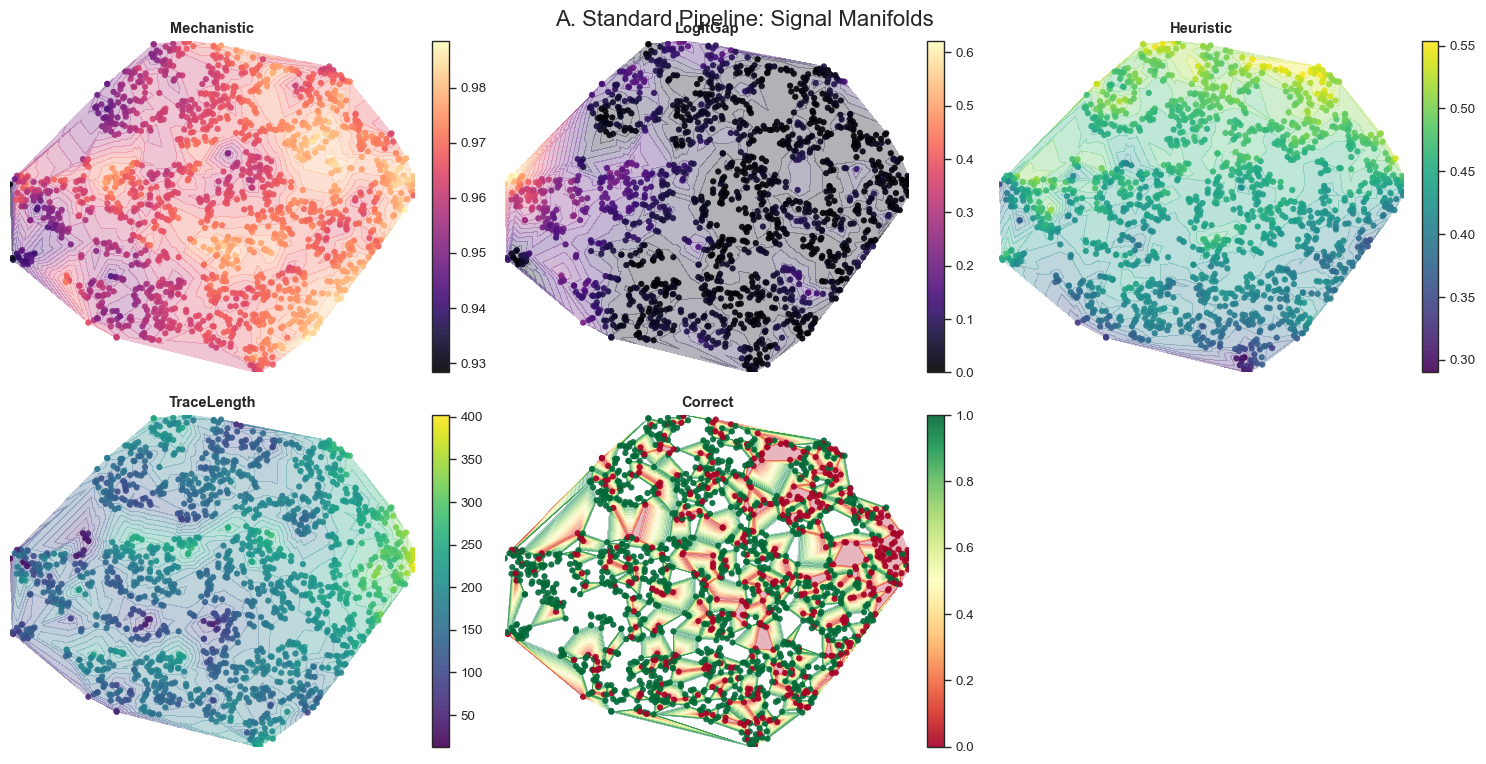
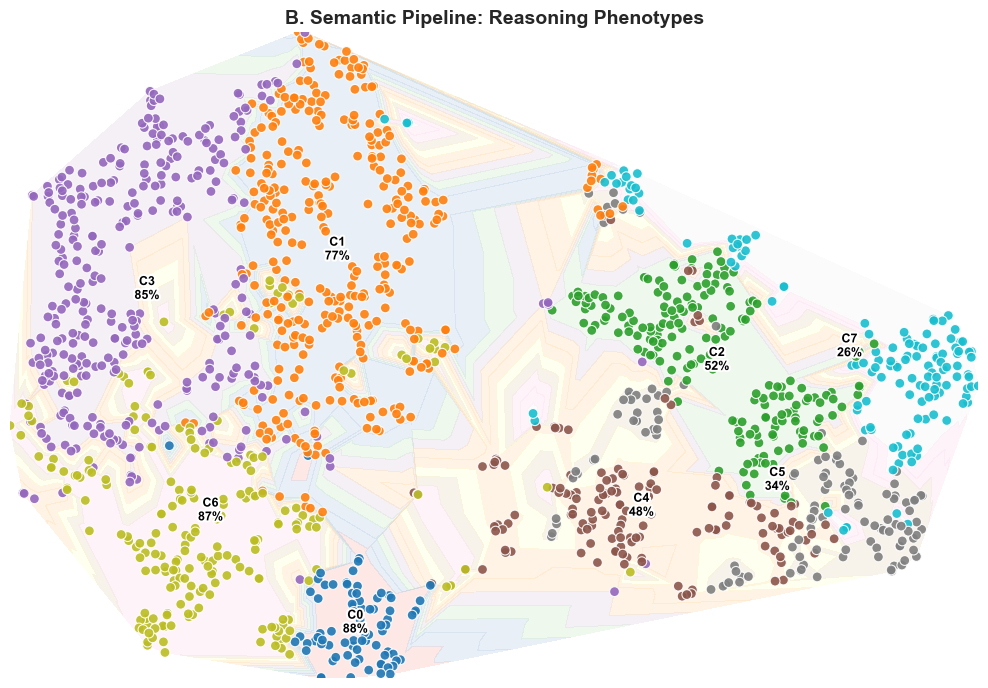
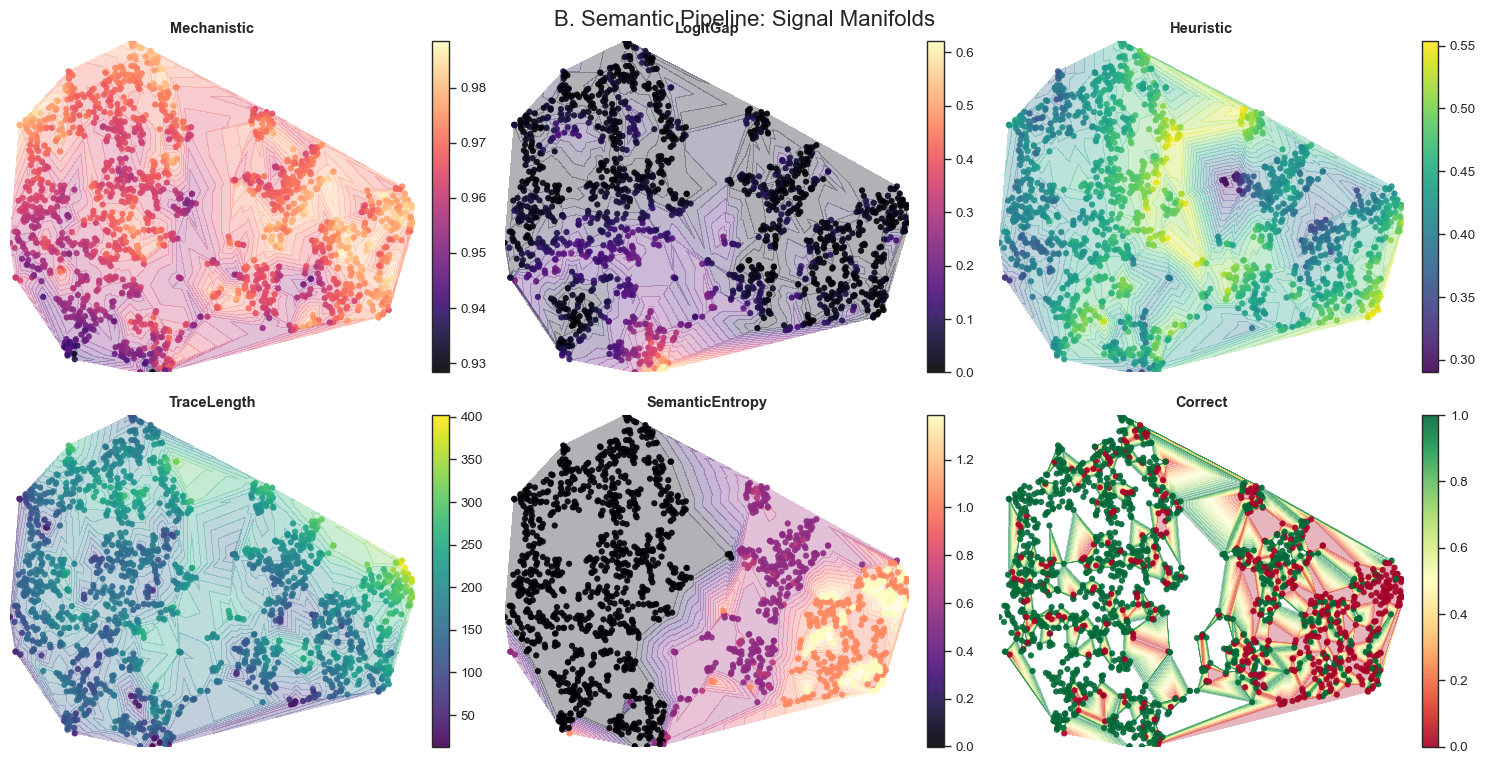

In [1]:
# %% [markdown]
# # Unified Uncertainty Analysis: SFT vs RL Reasoning Phenotypes
# 
# ## Abstract
# This notebook implements a complete pipeline for analyzing LLM uncertainty. It processes token-level traces to compute key uncertainty signals, clusters them into "Reasoning Phenotypes," and evaluates their predictive power.
# 
# **Key Features:**
# *   **Dual Manifold Analysis:** Comparisons of reasoning landscapes **with** and **without** Semantic Entropy.
# *   **Interpolated Heatmaps:** Continuous background visualization of uncertainty metrics across the manifold ("coloring the background").
# *   **Predictive Benchmarking:** AUROC, AUARC, and ECE evaluation of uncertainty baselines vs. semantic oracles.
# *   **Token Forensics:** Identification of specific tokens driving mechanistic uncertainty.

# %% [code]
import sqlite3
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patheffects as PathEffects
import json
import re
import io
import base64
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, brier_score_loss
from IPython.display import display, HTML

# --- CONFIGURATION ---
DB_PATH = "db/results.sqlite"
sns.set_theme(style="white", context="paper", font_scale=1.1)

# --- CSS FOR DASHBOARD (Preserving the "Nice Things") ---
DASHBOARD_CSS = """
<style>
    :root { --bg: #fff; --text: #2c3e50; --acc: #3498db; --border: #e0e0e0; --pass: #27ae60; --fail: #c0392b; --warn: #f39c12; }
    .db-cont { font-family: 'Segoe UI', sans-serif; max-width: 100%; color: var(--text); }
    .db-head { padding: 15px; border-bottom: 3px solid var(--acc); margin-bottom: 20px; background: #f8f9fa; }
    .pipeline-header { font-size: 1.5em; font-weight: bold; margin: 30px 0 15px 0; border-left: 5px solid var(--acc); padding-left: 10px; }
    
    /* Cluster Cards */
    .c-card { border: 1px solid var(--border); margin-bottom: 20px; border-radius: 6px; box-shadow: 0 2px 5px rgba(0,0,0,0.05); }
    .c-head { padding: 10px 15px; display: flex; justify-content: space-between; align-items: center; background: #f1f2f6; border-bottom: 1px solid var(--border); }
    .c-title { font-weight: bold; font-size: 1.1em; }
    .c-acc { font-size: 0.9em; font-weight: bold; }
    
    /* Metrics Table */
    .m-tbl { width: 100%; border-collapse: collapse; font-size: 0.9em; margin: 10px 0; }
    .m-tbl th { text-align: left; padding: 6px; color: #7f8c8d; border-bottom: 1px solid #ddd; }
    .m-tbl td { padding: 6px; border-bottom: 1px solid #eee; }
    
    /* Shift Bars (The nice visualization) */
    .s-bar-bg { width: 100px; height: 6px; background: #eee; position: relative; border-radius: 3px; display:inline-block; vertical-align:middle; }
    .s-bar-fill { height: 100%; position: absolute; border-radius: 3px; }
    .s-marker { position: absolute; top: -2px; bottom: -2px; width: 2px; background: #333; left: 50%; }
    
    /* Prediction Cards */
    .p-card { background: #fff; border: 1px solid var(--border); padding: 15px; margin-bottom: 10px; border-radius: 6px; }
    
    /* Token Badges */
    .tok { display: inline-block; padding: 2px 5px; border-radius: 3px; border: 1px solid #eee; font-family: monospace; font-size: 0.85em; margin: 2px; }
    .t-bad { background: #ffebee; color: #c0392b; border-color: #ef9a9a; }
    .t-good { background: #e8f5e9; color: #27ae60; border-color: #a5d6a7; }
    
    details { margin: 0; border-top: 1px solid #eee; }
    summary { padding: 10px 15px; cursor: pointer; background: #fff; color: var(--acc); font-weight: 500; }
    .ex { padding: 15px; background: #fafafa; font-family: monospace; font-size: 0.85em; max-height: 200px; overflow-y: auto; white-space: pre-wrap; }
</style>
"""

# %% [code]
# --- 1. DATA LOADING & FEATURE ENGINEERING ---
def load_data(db_path):
    conn = sqlite3.connect(db_path)
    try:
        # Get latest experiment
        exp = pd.read_sql("SELECT experiment_id FROM Experiments ORDER BY experiment_id DESC LIMIT 1", conn)
        exp_id = exp.iloc[0]['experiment_id']
        print(f"✅ Loading Experiment ID: {exp_id}")
    except:
        exp_id = 1
        
    query = f"""
    SELECT r.result_id, r.question_id_external, r.full_trace_text, r.is_correct,
           r.predicted_answer,
           r.uq_avg_entropy as 'Entropy', 
           r.uq_min_logit_gap as 'LogitGap', 
           r.uq_heuristic_score as 'Heuristic', 
           r.uq_mech_score as 'Mechanistic',
           r.uq_mech_trace
    FROM Results r WHERE r.experiment_id = {exp_id}
    """
    df = pd.read_sql(query, conn)
    conn.close()
    
    # Feature 1: Trace Length (Standard Baseline)
    df['TraceLength'] = df['full_trace_text'].fillna("").apply(lambda x: len(x.split()))
    
    # Feature 2: Semantic Entropy (Oracle/Expensive)
    # We group by question ID to calculate consistency across samples
    def calc_se(g):
        ans = g['predicted_answer'].fillna("").astype(str).str.strip().str.lower()
        probs = ans.value_counts(normalize=True)
        return -np.sum(probs * np.log(probs + 1e-10))
    
    if 'question_id_external' in df.columns:
        se_map = df.groupby('question_id_external').apply(calc_se, include_groups=False)
        df['SemanticEntropy'] = df['question_id_external'].map(se_map)
    else:
        df['SemanticEntropy'] = 0.0

    df['Correct'] = df['is_correct'].astype(int)
    
    # Fill NaNs for safety
    metrics = ['Entropy', 'LogitGap', 'Heuristic', 'Mechanistic', 'SemanticEntropy', 'TraceLength']
    df[metrics] = df[metrics].fillna(0)
    
    return df

df = load_data(DB_PATH)

# %% [code]
# --- 2. THE PHENOTYPE PIPELINE CLASS ---
# This class encapsulates the "Nice Pipeline" logic so we can run it twice
class PhenotypePipeline:
    def __init__(self, df, features, name="Standard"):
        self.df = df.copy()
        self.features = features
        self.name = name
        self.scaler = StandardScaler()
        # Using fixed random_state for reproducibility across runs
        self.tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(df)-1), init='pca', learning_rate='auto')
        self.kmeans = KMeans(n_clusters=8, random_state=42) # 8 Phenotypes
        
        self.X_scaled = None
        self.embedding = None
        self.global_means = None
        self.global_sds = None
        
    def run(self):
        # 1. Scale
        self.X_scaled = self.scaler.fit_transform(self.df[self.features])
        
        # 2. t-SNE
        print(f"[{self.name}] Running t-SNE Manifold...")
        self.embedding = self.tsne.fit_transform(self.X_scaled)
        self.df['x'] = self.embedding[:, 0]
        self.df['y'] = self.embedding[:, 1]
        
        # 3. Clustering
        print(f"[{self.name}] Identifying Phenotypes...")
        self.df['Cluster'] = self.kmeans.fit_predict(self.X_scaled)
        
        # 4. Global Stats (for the shift bars)
        self.global_means = self.df[self.features].mean()
        self.global_sds = self.df[self.features].std()
        
    def plot_cluster_map(self):
        """Graph A: The Main Phenotype Map (Clusters)"""
        fig, ax = plt.subplots(figsize=(10, 7), dpi=100)
        
        # Background density (tricontourf for background coloring)
        try:
            ax.tricontourf(self.df['x'], self.df['y'], self.df['Cluster'], levels=12, cmap='Pastel1', alpha=0.3)
        except: pass
            
        scatter = ax.scatter(self.df['x'], self.df['y'], c=self.df['Cluster'], cmap='tab10', s=50, edgecolors='w', alpha=0.9)
        
        # Annotate Centers with Accuracy
        centers = self.df.groupby('Cluster')[['x', 'y']].mean()
        accs = self.df.groupby('Cluster')['Correct'].mean() * 100
        
        for i, row in centers.iterrows():
            txt = ax.text(row['x'], row['y'], f"C{i}\n{accs[i]:.0f}%", 
                          ha='center', va='center', fontsize=9, fontweight='bold', color='black')
            # Add stroke for readability
            txt.set_path_effects([PathEffects.withStroke(linewidth=3, foreground='white')])
            
        ax.set_title(f"{self.name} Pipeline: Reasoning Phenotypes", fontsize=14, fontweight='bold')
        ax.axis('off')
        
        return self._fig_to_b64(fig)

    def plot_feature_grid(self):
        """Graph B: The Grid of Heatmaps with Background Coloring"""
        # We plot all features + Correctness
        plot_feats = self.features + ['Correct']
        n_feats = len(plot_feats)
        cols = 3
        rows = (n_feats + cols - 1) // cols
        
        fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows), dpi=100)
        axes = axes.flatten()
        
        for i, feat in enumerate(plot_feats):
            ax = axes[i]
            x, y, z = self.df['x'], self.df['y'], self.df[feat]
            
            # Determine Colors
            if feat == 'Correct': cmap = 'RdYlGn'
            # High uncertainty (bad) usually = Yellow/Green in Viridis? Let's use specific maps
            elif feat in ['Mechanistic', 'Entropy', 'LogitGap', 'SemanticEntropy']: cmap = 'magma' # Dark=Low (Good), Light=High (Bad)
            else: cmap = 'viridis' 

            # --- Background Interpolation (The requested update) ---
            try:
                # tricontourf fills the background based on the scatter points
                cntr = ax.tricontourf(x, y, z, levels=20, cmap=cmap, alpha=0.3)
            except: pass
            
            # Scatter Points on top
            sc = ax.scatter(x, y, c=z, cmap=cmap, s=20, edgecolors='none', alpha=0.9)
            
            ax.set_title(feat, fontweight='bold')
            ax.axis('off')
            plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
            
        # Hide empty axes
        for j in range(i+1, len(axes)): axes[j].axis('off')
        
        plt.suptitle(f"{self.name} Pipeline: Signal Manifolds", fontsize=16, y=0.95)
        return self._fig_to_b64(fig)
    
    def generate_html_cards(self):
        """Generates the 'Nice' HTML Cards from interpret.ipynb"""
        html = ""
        clusters = sorted(self.df['Cluster'].unique())
        
        for c in clusters:
            sub = self.df[self.df['Cluster'] == c]
            acc = sub['Correct'].mean() * 100
            count = len(sub)
            
            # Color header by accuracy
            if acc >= 80: h_col = "var(--pass)"
            elif acc >= 50: h_col = "var(--warn)"
            else: h_col = "var(--fail)"
            
            # Metrics Table with Shift Bars
            m_rows = ""
            for f in self.features:
                mean_val = sub[f].mean()
                g_mean = self.global_means[f]
                g_sd = self.global_sds[f]
                # Z-score for shift
                z_score = (mean_val - g_mean) / (g_sd + 1e-9)
                
                # Bar Logic: 0 is center (50%), +/- 3 SD maps to 0%/100%
                pct = 50 + (z_score * 16.6) 
                pct = max(5, min(95, pct))
                
                # Color the bar based on deviation
                bar_color = "#7f8c8d"
                if abs(z_score) > 0.5:
                    # Logic: High Uncertainty (Positive Z) is usually Bad (Fail color)
                    # Except Correctness/Length where context matters. Simplified:
                    bar_color = "var(--acc)"
                
                bar_html = f"""
                <div class='s-bar-bg'>
                    <div class='s-marker'></div>
                    <div class='s-bar-fill' style='left: {min(50, pct)}%; width: {abs(pct-50)}%; background: {bar_color}'></div>
                </div>
                """
                
                m_rows += f"<tr><td><b>{f}</b></td><td>{mean_val:.3f}</td><td style='color:{bar_color}'>{z_score:+.1f} SD</td><td>{bar_html}</td></tr>"
            
            # Representative Example (Nearest to Centroid)
            center = self.kmeans.cluster_centers_[c]
            dists = np.linalg.norm(self.X_scaled[sub.index] - center, axis=1)
            ex_idx = sub.index[np.argmin(dists)]
            ex_text = self.df.loc[ex_idx, 'full_trace_text'][:300] + "..."
            
            html += f"""
            <div class='c-card'>
                <div class='c-head' style='border-left: 5px solid {h_col}'>
                    <div class='c-title'>Cluster {c}</div>
                    <div class='c-acc'>{acc:.1f}% Acc (n={count})</div>
                </div>
                <div style='display:flex; flex-wrap:wrap'>
                    <div style='flex:1; min-width:300px; padding:10px'>
                        <table class='m-tbl'><thead><tr><th>Metric</th><th>Mean</th><th>Shift</th><th>Vis</th></tr></thead><tbody>{m_rows}</tbody></table>
                    </div>
                    <div style='flex:1; min-width:300px; padding:10px'>
                        <div style='font-size:0.8em; color:#666; margin-bottom:5px'><b>Representative Trace:</b></div>
                        <div class='ex'>{ex_text}</div>
                    </div>
                </div>
            </div>
            """
        return html

    def _fig_to_b64(self, fig):
        buf = io.BytesIO()
        plt.tight_layout()
        plt.savefig(buf, format='png', bbox_inches='tight')
        plt.close(fig)
        return base64.b64encode(buf.getvalue()).decode('utf-8')

# %% [code]
# --- 3. PREDICTOR & TOKENS (Parts C & D) ---
def analyze_predictors(df):
    target = 1 - df['Correct'] # Predict Failure
    
    # Define models as requested
    models = {
        "Baseline (Length)": ['TraceLength'],
        "Standard (No Sem)": ['TraceLength', 'Mechanistic', 'LogitGap', 'Heuristic'],
        "Full (With Sem)": ['TraceLength', 'Mechanistic', 'LogitGap', 'Heuristic', 'SemanticEntropy']
    }
    
    html = ""
    
    # Helper for AUARC
    def calc_auarc(y_true, y_prob):
        d = pd.DataFrame({'fail': y_true, 'prob': y_prob}).sort_values('prob', ascending=True)
        accs = []
        for i in range(0, len(d), max(1, int(len(d)*0.1))):
            accs.append(1 - d.iloc[i:]['fail'].mean())
        return np.mean(accs)
    
    for name, cols in models.items():
        X = StandardScaler().fit_transform(df[cols].fillna(0))
        y = target
        clf = LogisticRegression(class_weight='balanced', random_state=42).fit(X, y)
        probs = clf.predict_proba(X)[:, 1]
        
        # Metrics requested in email
        auroc = roc_auc_score(y, probs)
        ece = brier_score_loss(y, probs)
        auarc = calc_auarc(y, probs)
        
        # Nicer coefficients
        coef_str = " | ".join([f"{f}: <b>{w:+.2f}</b>" for f,w in sorted(zip(cols, clf.coef_[0]), key=lambda x:-abs(x[1]))])
        
        html += f"""
        <div class='p-card'>
            <div style='font-weight:bold; color:var(--text)'>{name}</div>
            <div style='font-size:0.9em; margin-top:5px; margin-bottom:8px'>
                AUROC: <b>{auroc:.3f}</b> &nbsp;|&nbsp; AUARC: <b>{auarc:.3f}</b> &nbsp;|&nbsp; ECE: <b>{ece:.3f}</b>
            </div>
            <div style='font-size:0.8em; color:#555; background:#f9f9f9; padding:5px'>{coef_str}</div>
        </div>
        """
    return html

def analyze_tokens(df):
    # Flatten traces to find risky tokens
    token_stats = {}
    for _, row in df.iterrows():
        try:
            mech = json.loads(row['uq_mech_trace']) if row['uq_mech_trace'] else []
            words = re.findall(r'\w+', row['full_trace_text'])
            if mech and words:
                ratio = len(mech) / len(words)
                for i, w in enumerate(words):
                    if len(w) < 4: continue
                    idx = min(int(i*ratio), len(mech)-1)
                    if w not in token_stats: token_stats[w] = {'sum':0, 'n':0, 'err':0}
                    token_stats[w]['sum'] += mech[idx]
                    token_stats[w]['n'] += 1
                    if row['Correct'] == 0: token_stats[w]['err'] += 1
        except: continue
            
    # Filter & Sort
    res = []
    for w, d in token_stats.items():
        if d['n'] > 10:
            res.append({'Word': w, 'AvgMech': d['sum']/d['n'], 'FailRate': d['err']/d['n']})
    
    tdf = pd.DataFrame(res)
    if tdf.empty: return "No token data."
    
    # High Risk: High Uncertainty + High Fail Rate
    risky = tdf.sort_values(by=['AvgMech', 'FailRate'], ascending=False).head(15)
    # Safe: Low Uncertainty + Low Fail Rate
    safe = tdf[tdf['FailRate'] < 0.2].sort_values(by='AvgMech', ascending=True).head(15)
    
    def fmt(df, cls):
        return " ".join([f"<span class='tok {cls}'>{r.Word}</span>" for _, r in df.iterrows()])
    
    return f"""
    <div style='display:flex; gap:20px'>
        <div style='flex:1' class='p-card'>
            <div style='font-weight:bold; color:var(--fail)'>High Risk Tokens (Uncertain & Incorrect)</div>
            <div style='margin-top:10px'>{fmt(risky, 't-bad')}</div>
        </div>
        <div style='flex:1' class='p-card'>
            <div style='font-weight:bold; color:var(--pass)'>Safe Anchors (Certain & Correct)</div>
            <div style='margin-top:10px'>{fmt(safe, 't-good')}</div>
        </div>
    </div>
    """

# %% [code]
# --- 4. EXECUTION & REPORT GENERATION ---

# Pipeline A: Standard
pipe_a = PhenotypePipeline(df, ['Mechanistic', 'LogitGap', 'Heuristic', 'TraceLength'], "A. Standard")
pipe_a.run()
img_a_map = pipe_a.plot_cluster_map()
img_a_grid = pipe_a.plot_feature_grid()

# Pipeline B: Semantic (Oracle)
pipe_b = PhenotypePipeline(df, ['Mechanistic', 'LogitGap', 'Heuristic', 'TraceLength', 'SemanticEntropy'], "B. Semantic")
pipe_b.run()
img_b_map = pipe_b.plot_cluster_map()
img_b_grid = pipe_b.plot_feature_grid()
html_cards = pipe_b.generate_html_cards() # Show detailed cards for the full model

# Predictors & Tokens
html_preds = analyze_predictors(df)
html_tokens = analyze_tokens(df)

# Assemble Full HTML
full_html = DASHBOARD_CSS + f"""
<div class='db-cont'>
    <div class='db-head'><h2>Unified Uncertainty Analysis</h2></div>
    
    <div class='pipeline-header'>1. Standard Pipeline (Computationally Cheap)</div>
    <div style='display:flex; flex-wrap:wrap; gap:20px'>
        <div style='flex:1; min-width:400px'><img src='data:image/png;base64,{img_a_map}' style='width:100%'></div>
        <div style='flex:2; min-width:400px'><img src='data:image/png;base64,{img_a_grid}' style='width:100%'></div>
    </div>
    
    <div class='pipeline-header'>2. Semantic Pipeline (Oracle / Expensive)</div>
    <div style='display:flex; flex-wrap:wrap; gap:20px'>
        <div style='flex:1; min-width:400px'><img src='data:image/png;base64,{img_b_map}' style='width:100%'></div>
        <div style='flex:2; min-width:400px'><img src='data:image/png;base64,{img_b_grid}' style='width:100%'></div>
    </div>
    
    <div class='pipeline-header'>3. Reasoning Phenotypes (Semantic Clusters)</div>
    {html_cards}
    
    <div class='pipeline-header'>4. Predictive & Token Forensics</div>
    <div style='display:flex; gap:20px; flex-wrap:wrap'>
        <div style='flex:1; min-width:350px'>
            <h4>Predictive Modeling</h4>
            {html_preds}
        </div>
        <div style='flex:1; min-width:350px'>
            <h4>Token Drivers</h4>
            {html_tokens}
        </div>
    </div>
</div>
"""

display(HTML(full_html))